In [1]:
#Final filter of the metadata
#author: Sheng-Kai Hsu
#created: 2025.04.03
#last edited: 2025.04.03


In [601]:
rm(list=ls())

In [602]:
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_2025.04.03_CH.csv",header = T)

In [603]:
TABASCO = read.csv("/workdir/sh2246/p_phyloGWAS/data/tabasco_Poaceae_20250402.csv")
# TABASCO = merge(TABASCO,metadata[,c(1,9)],by = "assemblyID",all.x = T)
# TABASCO = TABASCO[!duplicated(TABASCO[,1]),]
# rownames(TABASCO) = TABASCO$assemblyID

In [604]:
taxanomicGroup = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_taxonomic_groups_subtribeAdded_SKH20250402.csv",header = T)
taxanomicGroup = taxanomicGroup[!duplicated(taxanomicGroup$assemblyID),]
rownames(taxanomicGroup) = taxanomicGroup$assemblyID

In [605]:
metadata_new = metadata[,c(1:4,8:10)]

In [606]:
metadata_new = merge(metadata_new,TABASCO[,1:5],by = 'assemblyID',all.x = T)

In [607]:
metadata_new = merge(metadata_new,taxanomicGroup[,-2],by = 'assemblyID',all.x = T)

In [608]:
metadata_new = metadata_new[!duplicated(metadata_new[,1]),]

In [609]:
nrow(metadata_new)

[1] 808

In [610]:
# Toby's additional name changes and filtering
metadata_new[metadata_new$assemblyID%in%"AN21TNTL0362",3] = "Saccharum baldwinii"
metadata_new[metadata_new$assemblyID%in%"AN21TNTL0363",3] = "Erianthus giganteus"
metadata_new[metadata_new$assemblyID%in%"AN20T004",3] = "Schizachyrium brevifolium"
metadata_new[metadata_new$assemblyID%in%"AN21TSTL0036",3] = "Omit"

In [611]:
# bad samples (-13)
metadata_new$wrongSample = metadata_new$correctSpecies != "Omit"

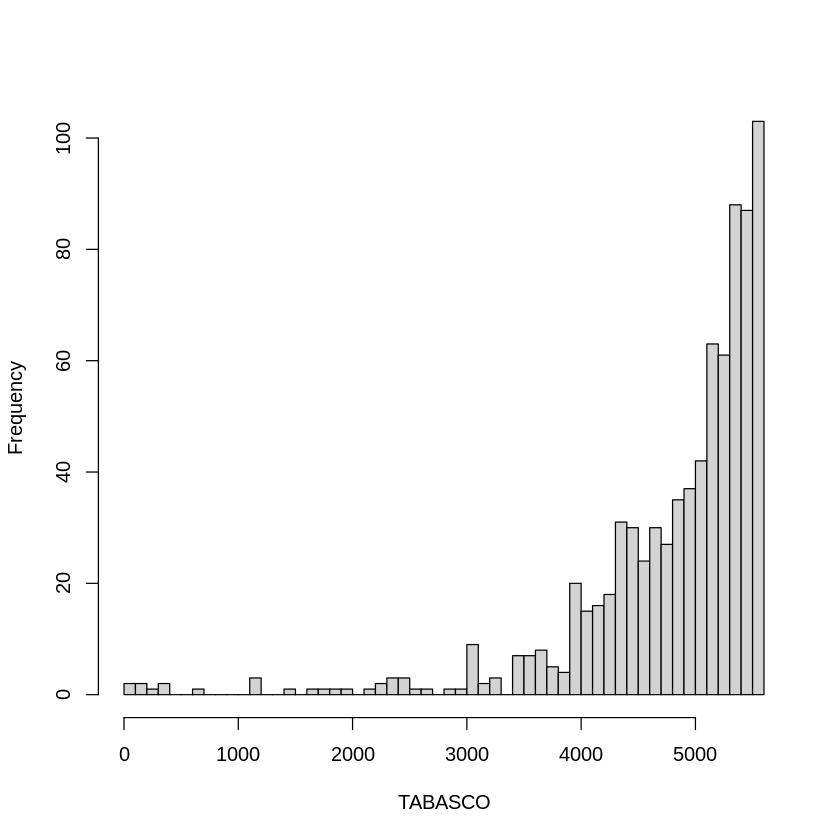

In [612]:
# TABASCO complete+duplicate
hist((metadata_new$complete + metadata_new$duplicated),breaks = seq(0,5600,100),main = "",xlab = "TABASCO")

In [613]:
# TABASCO complete+duplicate >= 2796/5592  (-(26 + 6 NA) = -32)
metadata_new$lowTABASCO = (metadata_new$complete + metadata_new$duplicated) >= 2796

In [614]:
# Charlie's bad list (-5; 10 were bad TABASCO or NA in the first place)
cohBadSamples = c("RSPBVictoria1.0","lpBroSter1.1_alternate_haplotype","CM05836_v1.1","ASM90020540v1",
                  "Hordeum_pubiflorum_assembly1","4AgS","ASM63269v1","Pp-Kellogg1297-DRAFT-PanAnd-1.0",
                  "ASM3043976v1","ASM2338475v1","ASM2338477v1","ASM2338479v1","SRR2219562","ERR5945840",
                  "Zoysia_sinica")
metadata_new$CHList = !metadata_new$assemblyID%in%cohBadSamples

In [615]:
# A!0XX -short read of long read (-12)
metadata_new$QCshortread = !grepl("^A10",metadata_new$assemblyID)

In [616]:
# duplicates pick the best TABASCO (-18)
metadata_new_noEcotype = metadata_new[is.na(metadata_new$CorrectEcotype),]
metadata_new_withEcotype = metadata_new[!is.na(metadata_new$CorrectEcotype),]

In [617]:
metadata_new_withEcotype = metadata_new_withEcotype[order(metadata_new_withEcotype$complete+metadata_new_withEcotype$duplicated,decreasing = T),]

In [618]:
metadata_new_withEcotype = metadata_new_withEcotype[order(metadata_new_withEcotype$correctSpecies),]

In [619]:
which(duplicated(paste0(metadata_new_withEcotype$correctSpecies,metadata_new_withEcotype$CorrectEcotype)))

[1]  33  34  71 106 127 135 263 271 278 279 280 357 389 405 408 409 410 411 412
[20] 413 415 417 418 419 591 592 593 646 647 671

In [620]:
metadata_new_withEcotype[277:280,]

,assemblyID,tracker_sample_name,correctSpecies,CorrectEcotype,lifeHistory,technology,source,complete,duplicated,fraged,missing,clade,subfamily,tribe,subtribe,wrongSample,lowTABASCO,CHList,QCshortread
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
313,AN21TSTL0225,AN21TSTL0225,Eriochrysis cayennensis,AUB & Bookout 109,perennial,Illumina,PanAnd,5311,83,189,9,PACMAD,Panicoideae,Andropogoneae,NA,TRUE,TRUE,TRUE,TRUE
309,AN21TSTL0221,AN21TSTL0221,Eriochrysis cayennensis,AUB & Bookout 109,perennial,Illumina,PanAnd,5306,84,193,9,PACMAD,Panicoideae,Andropogoneae,NA,TRUE,TRUE,TRUE,TRUE
77,AN20TSCR000208,AN20TSCR000208,Eriochrysis cayennensis,AUB & Bookout 109,perennial,Illumina,PanAnd,5289,82,213,8,PACMAD,Panicoideae,Andropogoneae,NA,TRUE,TRUE,TRUE,TRUE
149,AN21TNTL0176,AN20TSCR000208,Eriochrysis cayennensis,AUB & Bookout 109,perennial,Illumina,PanAnd,5265,87,231,9,NA,NA,NA,NA,TRUE,TRUE,TRUE,TRUE


In [621]:
metadata_new_withEcotype$dupSample = !duplicated(paste0(metadata_new_withEcotype$correctSpecies,metadata_new_withEcotype$CorrectEcotype))

In [622]:
metadata_new_noEcotype$dupSample = TRUE

In [623]:
metadata_new = rbind(metadata_new_noEcotype,metadata_new_withEcotype)

In [624]:
apply(metadata_new[,16:20],2,summary)

$wrongSample
   Mode   FALSE    TRUE 
logical      13     795 

$lowTABASCO
   Mode   FALSE    TRUE    NA's 
logical      27     774       7 

$CHList
   Mode   FALSE    TRUE 
logical      15     793 

$QCshortread
   Mode   FALSE    TRUE 
logical      12     796 

$dupSample
   Mode   FALSE    TRUE 
logical      30     778 


In [625]:
# NA to FALSE (to filter)
metadata_new[,16:20][is.na(metadata_new[,16:20])] = FALSE

In [626]:
write.csv(metadata_new,"/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_2025.04.07.csv", row.names = F)

In [627]:
# keep all T across the five filters
metadata_hardFiltered = metadata_new[apply(metadata_new[,16:20],1,all),]

In [628]:
dim(metadata_new)
dim(metadata_hardFiltered)

[1] 808  20

[1] 728  20

In [629]:
apply(metadata_new[,16:20],2,table)

,wrongSample,lowTABASCO,CHList,QCshortread,dupSample
FALSE,13,34,15,12,30
TRUE,795,774,793,796,778


In [630]:
write.csv(metadata_hardFiltered,"/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_filtered_2025.04.07.csv", row.names = F)